<a href="https://colab.research.google.com/github/192425213simats-a11y/MLA0401---DEEP-LEARNING/blob/main/2.%202%20class%20Confusion%20matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

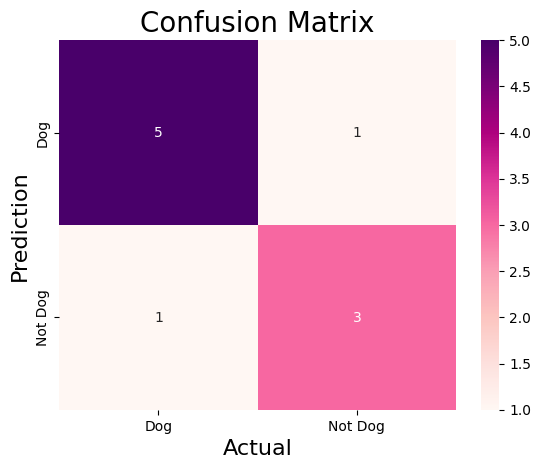

In [1]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Actual results
actual = np.array([
    'Dog','Dog','Dog','Not Dog','Dog',
    'Not Dog','Dog','Dog','Not Dog','Not Dog'
])

# Model predictions
predicted = np.array([
    'Dog','Not Dog','Dog','Not Dog','Dog',
    'Dog','Dog','Dog','Not Dog','Not Dog'
])

# Create confusion matrix
conf_matrix = confusion_matrix(actual, predicted)

# Display confusion matrix
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='g',
    xticklabels=['Dog','Not Dog'],
    yticklabels=['Dog','Not Dog'],
    cmap='RdPu'
)

plt.ylabel("Prediction", fontsize=16)
plt.xlabel("Actual", fontsize=16)
plt.title("Confusion Matrix", fontsize=20)

plt.show()

Accuracy: 0.9743589743589743
Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        17
     class_1       0.96      1.00      0.98        22

    accuracy                           0.97        39
   macro avg       0.98      0.97      0.97        39
weighted avg       0.98      0.97      0.97        39

Precision: 0.96
Recall: 1.00
F1 Score: 0.98


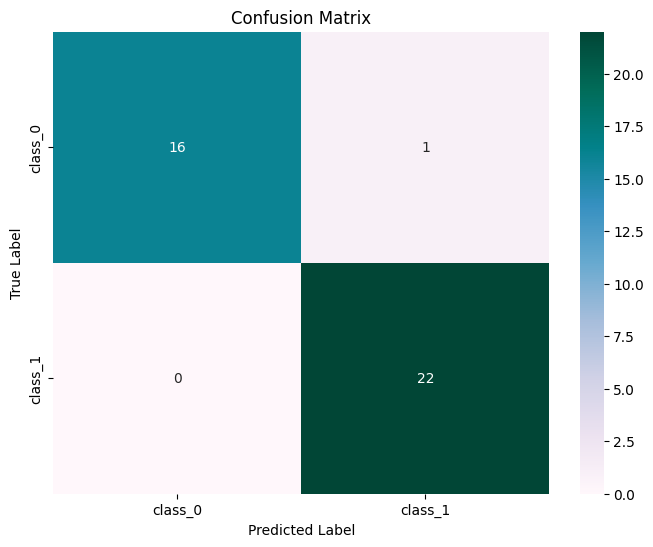

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# Load wine dataset
wine = load_wine()

# Convert dataset into DataFrame
data = pd.DataFrame(
    data=wine.data,
    columns=wine.feature_names
)

# Add target column
data['Target'] = wine.target

# Remove class 2 (only binary classification)
data = data[data['Target'] != 2]

# Separate features and target
x = data.drop('Target', axis=1)
y = data['Target']

# Split dataset into training and testing data
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=1
)

# Create Decision Tree model
model = DecisionTreeClassifier(random_state=1)

# Train the model
model.fit(x_train, y_train)

# Prediction
y_pred = model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
class_report = classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names[:2]
)

print("Classification Report:\n", class_report)

# Precision, Recall, F1 Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='PuBuGn',
    xticklabels=wine.target_names[:2],
    yticklabels=wine.target_names[:2]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()